In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat, savemat
from scipy.spatial import cKDTree
from pathlib import Path

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "assets" / "raytrack_scene" / "scene.xml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the RayLoc project root.")

PROJECT_ROOT = find_project_root()
GENERATED_DIR = PROJECT_ROOT / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
RADIO_MAP_DIR = GENERATED_DIR / "radio_map_lab1_27freq"
FREQ_DISTANCE_DIR = GENERATED_DIR / "freq_distance"
FREQ_DISTANCE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# =========================
# User settings
# =========================

base_dir = PROJECT_ROOT

# Station order must match the freq_map*.mat indexing.
# upper_BS_name = ["Roof", "Lab1", "Lab2", "Chem"]
bs_names = ["Roof", "Lab1", "Lab2", "Chem"]

# Lab1-only configuration.
# bs_names = ["Lab1"]

bs_to_map_id = {
    "Roof": 0,
    "Lab1": 1,
    "Lab2": 2,
    "Chem": 3,
}

date_list = [
    "11-14-1", "11-14-2", "11-14-3", "11-14-4", "11-14-5", "11-14-6",
    "11-14-7", "11-26-8", "11-26-9", "11-26-10"
]

# MATLAB used data(61:end, ...)
# Python is 0-indexed, so row 61 in MATLAB corresponds to index 60 in Python.
start_row = 60

# Frequency setting.
# MATLAB used data(:, :, 14), which is MATLAB 1-based.
# Python equivalent is freq_idx = 13.
# Set use_all_freqs=True to process all frequencies.
use_all_freqs = True

# If use_all_freqs=False, use this frequency index.
freq_idx = 13

output_dir = FREQ_DISTANCE_DIR
output_dir.mkdir(exist_ok=True)

In [3]:
def load_mat_variable(mat_path, var_name):
    """
    Load a variable from a MATLAB .mat file.
    Works for standard scipy-readable .mat files.
    """
    mat = loadmat(mat_path)
    if var_name not in mat:
        raise KeyError(f"{var_name} not found in {mat_path}. Available keys: {mat.keys()}")
    return mat[var_name]


def load_csv_numeric(csv_path):
    """
    Load numeric CSV.
    Assumes columns are:
        col 0: latitude
        col 1: longitude
        col 2...: RSSI or multi-frequency RSSI
    """
    df = pd.read_csv(csv_path)
    return df.to_numpy(dtype=float)


def nearest_indices_latlon(query_latlon, ref_latlon):
    """
    Find nearest point in ref_latlon for each query point.

    query_latlon: shape [N, 2]
    ref_latlon:   shape [M, 2]

    Returns:
        nearest_idx: shape [N]
        nearest_dist_deg: shape [N]
    """
    tree = cKDTree(ref_latlon)
    nearest_dist_deg, nearest_idx = tree.query(query_latlon, k=1)
    return nearest_idx, nearest_dist_deg


def extract_measured_rssi_for_locations(
    locations,
    station_name,
    date_list,
    base_dir,
    start_row=60,
):
    """
    For one BS/station:
        For every target location, find the nearest trajectory point
        among all date files, then extract its measured RSSI vector.

    Returns:
        measured_rssi: [N, K]
            K = number of RSSI columns in CSV.
        nearest_info: dict
            Useful debug information.
    """

    n_points = locations.shape[0]

    best_dist = np.full(n_points, np.inf)
    best_date_idx = np.full(n_points, -1, dtype=int)
    best_row_idx = np.full(n_points, -1, dtype=int)
    best_latlon = np.full((n_points, 2), np.nan)

    # Store candidate data so that we can extract RSSI later.
    loaded_data = {}

    folder = base_dir / "data" / "experimental_standardized" / f"Station-{station_name}" / f"{station_name.lower()} data"

    for d_idx, date in enumerate(date_list):
        csv_path = folder / f"{date}-interpolated.csv"

        if not csv_path.exists():
            print(f"[Warning] Missing file: {csv_path}")
            continue

        data = load_csv_numeric(csv_path)
        loaded_data[d_idx] = data

        # MATLAB: data(61:end, 1:2)
        traj_latlon = data[start_row:, 0:2]

        nearest_local_idx, nearest_dist_deg = nearest_indices_latlon(
            query_latlon=locations,
            ref_latlon=traj_latlon
        )

        # Convert local index within data[start_row:] back to global CSV row index.
        nearest_global_idx = nearest_local_idx + start_row

        update_mask = nearest_dist_deg < best_dist

        best_dist[update_mask] = nearest_dist_deg[update_mask]
        best_date_idx[update_mask] = d_idx
        best_row_idx[update_mask] = nearest_global_idx[update_mask]
        best_latlon[update_mask] = data[nearest_global_idx[update_mask], 0:2]

    # Determine RSSI dimension from the first loaded file.
    if len(loaded_data) == 0:
        raise RuntimeError(f"No CSV files loaded for station {station_name}.")

    example_data = next(iter(loaded_data.values()))
    num_rssi_cols = example_data.shape[1] - 2

    if num_rssi_cols <= 0:
        raise ValueError(
            f"CSV for {station_name} does not appear to contain RSSI columns after lat/lon."
        )

    measured_rssi = np.full((n_points, num_rssi_cols), np.nan)

    for i in range(n_points):
        d_idx = best_date_idx[i]
        row_idx = best_row_idx[i]

        if d_idx < 0 or row_idx < 0:
            continue

        data = loaded_data[d_idx]
        measured_rssi[i, :] = data[row_idx, 2:]

    nearest_info = {
        "best_dist_degree": best_dist,
        "best_date_idx": best_date_idx,
        "best_row_idx": best_row_idx,
        "best_latlon": best_latlon,
    }

    return measured_rssi, nearest_info

In [4]:
def generate_distmaster27freq_for_one_bs(
    station_name,
    map_id,
    locations,
    base_dir,
    date_list,
    start_row=60,
    use_all_freqs=True,
    freq_idx=13,
    save_output=True,
):
    """
    Generate DISTMASTER27freq for one base station.

    Output:
        DISTMASTER: shape [H, W, N]
            DISTMASTER[x, y, i] is the RSSI mismatch between
            measured RSSI at test point i and simulated RSSI at map cell (x, y).

    If use_all_freqs=True:
        Use all common frequency dimensions between measured_rssi and freqMap.
        Distance = mean absolute difference over frequencies.

    If use_all_freqs=False:
        Use one frequency slice.
        Distance = absolute difference at freq_idx.
    """

    print(f"\n===== Processing station {station_name}, map_id={map_id} =====")

    # -------------------------
    # Load simulated radio map
    # -------------------------
    freq_map_path = base_dir / "data" / "external" / f"freq_map{map_id}.mat"
    freq_map = load_mat_variable(freq_map_path, "freqMap")

    # Expected shape: [H, W, F]
    if freq_map.ndim == 2:
        freq_map = freq_map[:, :, None]

    H, W, F = freq_map.shape
    N = locations.shape[0]

    print("freq_map shape:", freq_map.shape)

    # -------------------------
    # Extract measured RSSI
    # -------------------------
    measured_rssi, nearest_info = extract_measured_rssi_for_locations(
        locations=locations,
        station_name=station_name,
        date_list=date_list,
        base_dir=base_dir,
        start_row=start_row,
    )

    print("measured_rssi shape:", measured_rssi.shape)

    # -------------------------
    # Generate mismatch map
    # -------------------------
    DISTMASTER = np.full((H, W, N), np.nan, dtype=np.float32)

    if use_all_freqs:
        # Use all overlapping frequency columns.
        K = min(F, measured_rssi.shape[1])

        if K == 0:
            raise ValueError("No overlapping frequency dimension found.")

        print(f"Using all available frequencies: K={K}")

        sim_map = freq_map[:, :, :K].astype(np.float32)

        for i in range(N):
            meas_vec = measured_rssi[i, :K].astype(np.float32)

            if np.any(np.isnan(meas_vec)):
                continue

            # sim_map: [H, W, K]
            # meas_vec: [K]
            # dist: [H, W]
            dist = np.mean(np.abs(sim_map - meas_vec[None, None, :]), axis=2)

            DISTMASTER[:, :, i] = dist.astype(np.float32)

    else:
        # Use one frequency slice.
        if freq_idx < 0 or freq_idx >= F:
            raise IndexError(f"freq_idx={freq_idx} out of range for F={F}")

        print(f"Using single frequency slice: Python freq_idx={freq_idx}")

        sim_map = freq_map[:, :, freq_idx].astype(np.float32)

        # If measured_rssi has only one column, use that.
        # If it has many columns, use the same freq_idx.
        if measured_rssi.shape[1] == 1:
            meas_col = 0
        else:
            meas_col = freq_idx

        for i in range(N):
            meas_val = measured_rssi[i, meas_col]

            if np.isnan(meas_val):
                continue

            DISTMASTER[:, :, i] = np.abs(sim_map - meas_val).astype(np.float32)

    # Replace invalid values before normalization.
    DISTMASTER = np.nan_to_num(DISTMASTER, nan=np.inf, posinf=np.inf, neginf=np.inf)

    # -------------------------
    # Save output
    # -------------------------
    if save_output:
        output_path = FREQ_DISTANCE_DIR / f"DISTMASTER27freq{map_id}.mat"
        savemat(output_path, {"DISTMASTER": DISTMASTER})
        print(f"Saved: {output_path}")

        # Save diagnostic arrays as NPZ.
        debug_path = FREQ_DISTANCE_DIR / f"DISTMASTER27freq{map_id}_debug.npz"
        np.savez(
            debug_path,
            measured_rssi=measured_rssi,
            best_dist_degree=nearest_info["best_dist_degree"],
            best_date_idx=nearest_info["best_date_idx"],
            best_row_idx=nearest_info["best_row_idx"],
            best_latlon=nearest_info["best_latlon"],
        )
        print(f"Saved debug info: {debug_path}")

    return DISTMASTER, measured_rssi, nearest_info

In [5]:
# =========================
# Load target locations
# =========================

datalats = load_mat_variable(base_dir / "data/algorithm_inputs/fixed_location_latitudes.mat", "datalats").squeeze()
datalons = load_mat_variable(base_dir / "data/algorithm_inputs/fixed_location_longitudes.mat", "datalons").squeeze()

locations = np.column_stack([datalats, datalons])

print("locations shape:", locations.shape)

locations shape: (100, 2)


[-590.8905 -517.7171    1.5   ]
(1037, 1183, 27)


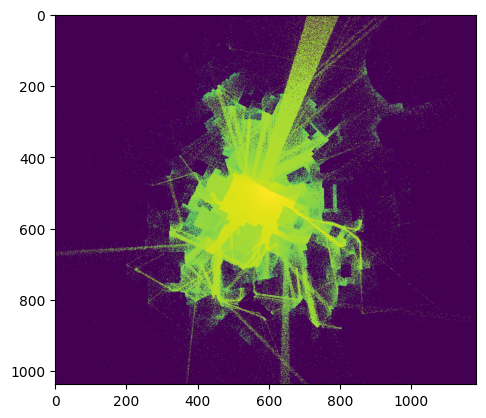

In [45]:
data = np.load(save_dir / "lab1_27freq_powermat.npz")
print(data["cell_centers"][0, 0])
print(data["powermat"].shape)
plt.imshow(data["powermat"][:,:,0])

In [56]:
import numpy as np
from pathlib import Path
from scipy.io import loadmat, savemat

base_dir = PROJECT_ROOT
save_dir = RADIO_MAP_DIR
out_dir = FREQ_DISTANCE_DIR
out_dir.mkdir(exist_ok=True)

# =========================
# Load simulated powermat
# =========================
# data = np.load(save_dir / "lab1_27freq_powermat.npz")
# powermat = data["powermat"]   # [H, W, 27], dB
# freqs = data["freqs"]

data = np.load(RADIO_MAP_DIR / "lab1_27freq_powermat.npz")
powermat = data["powermat"]   # [H, W, 27], dB
freqs = data["freqs"]

H, W, F = powermat.shape
assert F == 27

# =========================
# Load measured RSSI
# =========================
mat = loadmat(base_dir / "data" / "external" / "locationData1.mat")

# Select the first public variable in the MAT file.
keys = [k for k in mat.keys() if not k.startswith("__")]
print("MAT variables:", keys)

measured_rssi = mat[keys[0]]   # expected [100, 27]
measured_rssi = np.asarray(measured_rssi, dtype=np.float64)

print("measured_rssi shape:", measured_rssi.shape)
assert measured_rssi.shape[1] == 27

N = measured_rssi.shape[0]

# =========================
# Generate DISTMASTER
# =========================
# DISTMASTER[x, y, i] =
# mean absolute RSSI error over 27 frequencies
DISTMASTER = np.zeros((H, W, N), dtype=np.float32)

for i in range(N):
    # powermat: [H, W, 27]
    # measured_rssi[i]: [27]
    diff = np.abs(powermat - measured_rssi[i][None, None, :])
    DISTMASTER[:, :, i] = np.mean(diff, axis=2)

print("DISTMASTER shape:", DISTMASTER.shape)

# =========================
# Save
# =========================
savemat(out_dir / "DISTMASTER27freq1.mat", {
    "DISTMASTER": DISTMASTER,
    "freqs": freqs,
})

np.savez_compressed(
    out_dir / "DISTMASTER27freq1.npz",
    DISTMASTER=DISTMASTER,
    freqs=freqs,
    measured_rssi=measured_rssi,
)

print("Saved:", out_dir / "DISTMASTER27freq1.mat")

MAT variables: ['BS_RSSI']
measured_rssi shape: (100, 27)
DISTMASTER shape: (1037, 1183, 100)
Saved: /mnt/c/Users/NEWTLAB/Documents/Raytrack2/freqDistance/DISTMASTER27freq1.mat


In [65]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat, savemat
from scipy.spatial import cKDTree

base_dir = PROJECT_ROOT
station = "Lab1"
interval = 26
start_row = 60

date_list = [
    "11-14-1","11-14-2","11-14-3","11-14-4","11-14-5","11-14-6",
    "11-14-7","11-26-8","11-26-9","11-26-10"
]

datalats = loadmat(base_dir / "data/algorithm_inputs/fixed_location_latitudes.mat")["datalats"].squeeze()
datalons = loadmat(base_dir / "data/algorithm_inputs/fixed_location_longitudes.mat")["datalons"].squeeze()
locations = np.column_stack([datalats, datalons])
N = len(locations)

best_dist = np.full(N, np.inf)
best_date_idx = np.full(N, -1, dtype=int)
best_row_idx = np.full(N, -1, dtype=int)

loaded_data = {}

folder = base_dir / "data" / "experimental_standardized" / f"Station-{station}" / f"{station.lower()} data"

# 1. Find the nearest trajectory row for each test location.
for d_idx, date in enumerate(date_list):
    csv_path = folder / f"{date}-interpolated.csv"
    data = pd.read_csv(csv_path).to_numpy(dtype=float)
    loaded_data[d_idx] = data

    traj_latlon = data[start_row:, 0:2]
    tree = cKDTree(traj_latlon)

    dist, local_idx = tree.query(locations, k=1)
    global_idx = local_idx + start_row

    update = dist < best_dist
    best_dist[update] = dist[update]
    best_date_idx[update] = d_idx
    best_row_idx[update] = global_idx[update]

# 2. Move back by the configured interval to obtain the previous location.
lastlocs = np.full((N, 2), np.nan)
matched_locs = np.full((N, 2), np.nan)
valid_lastloc = np.zeros(N, dtype=bool)

for i in range(N):
    d_idx = best_date_idx[i]
    row_idx = best_row_idx[i]

    if d_idx < 0:
        continue

    data = loaded_data[d_idx]
    matched_locs[i] = data[row_idx, 0:2]

    last_row = row_idx - interval

    if last_row >= 0:
        lastlocs[i] = data[last_row, 0:2]
        valid_lastloc[i] = True

print("valid lastloc:", valid_lastloc.sum(), "/", N)

# 3. Save the result.
out_dir = FREQ_DISTANCE_DIR
out_dir.mkdir(exist_ok=True)

savemat(out_dir / "lastlocs_lab1_interval60.mat", {
    "lastlocs": lastlocs,
    "matched_locs": matched_locs,
    "best_dist": best_dist,
    "best_date_idx": best_date_idx,
    "best_row_idx": best_row_idx,
    "valid_lastloc": valid_lastloc,
    "interval": interval,
})

print("saved:", out_dir / "lastlocs_lab1_interval60.mat")

valid lastloc: 100 / 100
saved: /mnt/c/Users/NEWTLAB/Documents/Raytrack2/freqDistance/lastlocs_lab1_interval60.mat


In [9]:
import shapely
from utils import *
from pyproj import Transformer

#convert lat lon to coordinate
def sionna_coord(target_latlon):

    #bound
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    target_coord_flipped = (target_latlon[1], target_latlon[0])

    #find epsg code for projection
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    target_utm = to_utm.transform(target_coord_flipped[0], target_coord_flipped[1])

    #find center
    ground_utm = [to_utm.transform(lon, lat) for lon, lat in box]
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    ground_envelop = ground_polygon_utm.envelope
    center_x = ground_envelop.centroid.x
    center_y = ground_envelop.centroid.y

    #relative coord
    relative_coord = (target_utm[0] - center_x, target_utm[1] - center_y)

    return relative_coord

def sionna_coord_batch(latlon_array):
    """
    latlon_array: [N,2] -> [[lat, lon], ...]
    return: [N,2] -> [[x, y], ...]
    """

    latlon_array = np.asarray(latlon_array)
    assert latlon_array.shape[1] == 2, "Input must be Nx2 [lat, lon]"

    # =========================
    # 1. bounding box
    # =========================
    bl = (-122.312299126737, 47.65074792715546)
    ur = (-122.30187970485449, 47.65690207846001)
    box = [bl, (bl[0], ur[1]), ur, (ur[0], bl[1])]

    # =========================
    # 2. projection (computed once)
    # =========================
    EPSG_code = get_utm_epsg_code_from_gps(bl[0], bl[1])
    to_utm = Transformer.from_crs("EPSG:4326", EPSG_code, always_xy=True)

    # =========================
    # 3. compute center
    # =========================
    ground_utm = np.array([to_utm.transform(lon, lat) for lon, lat in box])
    ground_polygon_utm = shapely.geometry.Polygon(ground_utm)
    center_x = ground_polygon_utm.envelope.centroid.x
    center_y = ground_polygon_utm.envelope.centroid.y

    # =========================
    # 4. lat/lon -> utm (vectorized)
    # =========================
    lats = latlon_array[:, 0]
    lons = latlon_array[:, 1]

    # pyproj supports vectorized transforms.
    utm_x, utm_y = to_utm.transform(lons, lats)

    utm_x = np.array(utm_x)
    utm_y = np.array(utm_y)

    # =========================
    # 5. relative coord
    # =========================
    rel_x = utm_x - center_x
    rel_y = utm_y - center_y

    return np.stack([rel_x, rel_y], axis=1)

In [66]:
import numpy as np
from pathlib import Path
from scipy.io import loadmat, savemat

base_dir = PROJECT_ROOT
out_dir = FREQ_DISTANCE_DIR

lastloc_data = loadmat(out_dir / "lastlocs_lab1_interval60.mat")

lastlocs = lastloc_data["lastlocs"]              # [100,2], lat/lon
matched_locs = lastloc_data["matched_locs"]      # [100,2], lat/lon
valid_lastloc = lastloc_data["valid_lastloc"].squeeze().astype(bool)
interval = int(lastloc_data["interval"].squeeze())

powermat = np.load(
    RADIO_MAP_DIR / "lab1_27freq_powermat.npz"
)["powermat"]
H, W, _ = powermat.shape

# =========================
# Compute pivot_distance in Sionna coordinates.
# =========================
valid_pairs = (
    valid_lastloc
    & np.isfinite(lastlocs[:, 0])
    & np.isfinite(matched_locs[:, 0])
)

last_xy = sionna_coord_batch(lastlocs[valid_pairs])       # [N_valid,2]
match_xy = sionna_coord_batch(matched_locs[valid_pairs])  # [N_valid,2]

move_dist = np.linalg.norm(match_xy - last_xy, axis=1)
pivot_distance = np.median(move_dist)

print("pivot_distance:", pivot_distance)

# =========================
# Construct grid coordinates.
# Grid indices are treated as meters.
# This matches a power-map cell size of (1, 1) m.
# =========================
rowIdx, colIdx = np.meshgrid(
    np.arange(1, H + 1),
    np.arange(1, W + 1),
    indexing="ij"
)

# MATLAB-style offset
indexOffsetX, indexOffsetY = 590.8905, 517.7171

lastloc_dis = np.full((H, W, lastlocs.shape[0]), np.inf, dtype=np.float32)

for i in range(lastlocs.shape[0]):
    if not valid_lastloc[i]:
        continue

    last_xy_i = sionna_coord_batch(lastlocs[i:i+1])[0]  # [x,y]

    last_idx_row = last_xy_i[1] + indexOffsetY
    last_idx_col = last_xy_i[0] + indexOffsetX

    euclidean_dist = np.sqrt(
        (rowIdx - last_idx_row) ** 2 +
        (colIdx - last_idx_col) ** 2
    )

    lastloc_dis[:, :, i] = np.abs(euclidean_dist - pivot_distance)

savemat(out_dir / "DISTMASTERlastloc.mat", {
    "lastloc_dis": lastloc_dis,
    "pivot_distance": pivot_distance,
    "valid_lastloc": valid_lastloc,
    "interval": interval,
})

print("saved:", out_dir / "DISTMASTERlastloc.mat")
print("lastloc_dis shape:", lastloc_dis.shape)

pivot_distance: 22.071638819208154
saved: /mnt/c/Users/NEWTLAB/Documents/Raytrack2/freqDistance/DISTMASTERlastloc.mat
lastloc_dis shape: (1037, 1183, 100)


In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat, savemat

base_dir = PROJECT_ROOT
out_dir = FREQ_DISTANCE_DIR
algorithm_input_dir = base_dir / "data" / "algorithm_inputs"

station = "Lab1"
last_path_length = 10
freq_idx = 13  # Fourteenth frequency (915 MHz), zero-based index.

date_list = [
    "11-14-1","11-14-2","11-14-3","11-14-4","11-14-5","11-14-6",
    "11-14-7","11-26-8","11-26-9","11-26-10"
]

info = loadmat(out_dir / "lastlocs_lab1_interval60.mat")
best_date_idx = info["best_date_idx"].squeeze().astype(int)
best_row_idx = info["best_row_idx"].squeeze().astype(int)

folder = base_dir / "data" / "experimental_standardized" / f"Station-{station}" / f"{station.lower()} data"

loaded = {}
for d_idx, date in enumerate(date_list):
    csv_path = folder / f"{date}-interpolated.csv"
    loaded[d_idx] = pd.read_csv(csv_path).to_numpy(dtype=float)

N = len(best_row_idx)

# shape: [100, 11]
last_paths_915 = np.full(
    (N, last_path_length + 1),
    np.nan,
    dtype=np.float32
)

valid_lastpath = np.zeros(N, dtype=bool)

for i in range(N):
    d_idx = best_date_idx[i]
    row = best_row_idx[i]

    if d_idx < 0 or row < 0:
        continue

    start_row = row - last_path_length
    if start_row < 0:
        continue

    data = loaded[d_idx]

    # The first two columns are latitude/longitude; RSSI uses data[:, 2 + freq_idx].
    last_paths_915[i, :] = data[start_row:row+1, 2]

    valid_lastpath[i] = True

print("valid lastpath:", valid_lastpath.sum(), "/", N)
print("last_paths_915 shape:", last_paths_915.shape)

savemat(algorithm_input_dir / "lab1_last_path_rssi_915mhz.mat", {
    "last_paths": last_paths_915[:, :, np.newaxis],
    "valid_lastpath": valid_lastpath,
    "last_path_length": last_path_length,
    "freq_idx": freq_idx,
})

np.savez_compressed(
    algorithm_input_dir / "lab1_last_path_rssi_915mhz.npz",
    last_paths_915=last_paths_915,
    valid_lastpath=valid_lastpath,
    last_path_length=last_path_length,
    freq_idx=freq_idx,
)

print("saved:", algorithm_input_dir / "lab1_last_path_rssi_915mhz.mat")

valid lastpath: 100 / 100
last_paths_915 shape: (100, 11)
saved: data/algorithm_inputs/lab1_last_path_rssi_915mhz.mat


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter, maximum_filter

base_dir = PROJECT_ROOT
fd = FREQ_DISTANCE_DIR

# =========================
# Load data
# =========================
DIST = loadmat(fd / "DISTMASTER27freq1.mat")["DISTMASTER"]      # [H,W,100]
lastloc_dis = loadmat(fd / "DISTMASTERlastloc.mat")["lastloc_dis"]

# load 915 MHz last path
lp_data = loadmat(base_dir / "data/algorithm_inputs/lab1_last_path_rssi_915mhz.mat")
last_paths = lp_data["last_paths"].squeeze()   # [100,11]
valid_lastpath = lp_data["valid_lastpath"].squeeze().astype(bool)

pm = np.load(RADIO_MAP_DIR / "lab1_27freq_powermat.npz")
powermat_all = pm["powermat"]            # [H,W,27]
freqs = pm["freqs"]

idx_915 = np.argmin(np.abs(freqs - 915e6))
powermat_915 = powermat_all[:, :, idx_915]   # [H,W]

print("Using freq:", freqs[idx_915] / 1e6, "MHz")


datalats = loadmat(base_dir / "data/algorithm_inputs/fixed_location_latitudes.mat")["datalats"].squeeze()
datalons = loadmat(base_dir / "data/algorithm_inputs/fixed_location_longitudes.mat")["datalons"].squeeze()

H, W, N = DIST.shape
last_path_length = 10

# =========================
# Params
# =========================
a = 0
b = 1e-6
c = 0
peak_thresh_ratio = 0.1
smooth_sigma = 1.0

indexOffsetX, indexOffsetY = 590.8905, 517.7171

# Convert reference locations to Sionna coordinates.
test_xy = sionna_coord_batch(np.column_stack([datalats, datalons]))
actual_idx = np.column_stack([
    test_xy[:, 1] + indexOffsetY,   # row
    test_xy[:, 0] + indexOffsetX    # col
])

# =========================
# Helper
# =========================
def find_peaks_2d(score, thresh_ratio=0.1, neighborhood=15):
    local_max = score == maximum_filter(score, size=neighborhood)
    thresh = thresh_ratio * np.nanmax(score)
    mask = local_max & (score >= thresh) & np.isfinite(score)

    xs, ys = np.where(mask)
    pks = score[xs, ys]

    if len(pks) == 0:
        idx = np.nanargmax(score)
        x, y = np.unravel_index(idx, score.shape)
        return np.array([score[x, y]]), np.array([x]), np.array([y])

    order = np.argsort(pks)[::-1]
    return pks[order], xs[order], ys[order]


def get_path_rssi_915(xvals, yvals, powermat_915):
    vals = []
    for x, y in zip(xvals, yvals):
        x = int(np.clip(x, 0, powermat_915.shape[0] - 1))
        y = int(np.clip(y, 0, powermat_915.shape[1] - 1))
        vals.append(powermat_915[x, y])
    return np.array(vals)   # [11]


def path_score_for_peak(px, py, measured_path):
    best_err = np.inf

    for sx in range(px - last_path_length, px + last_path_length + 1):
        if sx < 0 or sx >= H:
            continue

        for sy in range(py - last_path_length, py + last_path_length + 1):
            if sy < 0 or sy >= W:
                continue

            dist = np.sqrt((sx - px)**2 + (sy - py)**2)

            if not (last_path_length - 1 <= dist <= last_path_length + 1):
                continue

            xvals = np.round(np.linspace(sx, px, last_path_length + 1)).astype(int)
            yvals = np.round(np.linspace(sy, py, last_path_length + 1)).astype(int)

            sim_path = get_path_rssi_915(xvals, yvals, powermat_915)  # [11]

            err = np.nanmean(np.abs(sim_path - measured_path))

            if err < best_err:
                best_err = err

    return 1.0 / (best_err + 1e-12)


# =========================
# Localization
# =========================
pred_idx = np.full((N, 2), np.nan)
ERROR = np.full(N, np.nan)

for i in range(N):

    cost = (DIST[:, :, i] + a) * (lastloc_dis[:, :, i] + b)
    score = 1.0 / (cost + 1e-12)
    score = gaussian_filter(score, sigma=smooth_sigma)

    pks, locs_x, locs_y = find_peaks_2d(
        score,
        thresh_ratio=peak_thresh_ratio,
        neighborhood=15
    )

    final_scores = pks.copy()

    # if valid_lastpath[i]:
    #     measured_path = last_paths[i]   # [11]

    #     path_scores = np.zeros(len(pks))
    #     for k in range(len(pks)):
    #         path_scores[k] = path_score_for_peak(
    #             int(locs_x[k]),
    #             int(locs_y[k]),
    #             measured_path
    #         )

    #     final_scores = pks * (path_scores + c)

    best = np.argmax(final_scores)

    est_row = locs_x[best]
    est_col = locs_y[best]

    pred_idx[i] = [est_row, est_col]

    ERROR[i] = np.sqrt(
        (actual_idx[i, 0] - est_row)**2 +
        (actual_idx[i, 1] - est_col)**2
    )

print("Median error:", np.nanmedian(ERROR))
print("Mean error:", np.nanmean(ERROR))
print("Valid samples:", np.sum(np.isfinite(ERROR)), "/", N)